<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/Practical%20Linear%20Algebra%20for%20Data%20Science/09.Orthogonal_Matrices_and_QR_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 9 - Matriks Ortogonal dan Dekomposisi QR (Orthogonal Matrices and QR Decomposition)

Notebook ini membahas matriks ortogonal, proyeksi ortogonal, ortogonalisasi Gram-Schmidt, dekomposisi QR, serta stabilitas numeriknya di Python.

### Identitas Mahasiswa
| Detail | Identitas |
| :--- | :--- |
| **Nama** | Rahmanda Afebrio Yuris Soesatyo |
| **NIM** | 1103223024 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# used to create non-regular subplots
import matplotlib.gridspec as gridspec


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

# Matriks Ortogonal


In [2]:
# specify the matrices
Q1 = np.array([ [1,-1],[1,1] ]) / np.sqrt(2)
Q2 = np.array([ [1,2,2],[2,1,-2],[-2,2,-1] ]) / 3

# should be I (to within rounding error...)
print( np.round(Q1.T @ Q1,8) ), print(' ')

print( np.round(Q2.T @ Q2,8) )

[[1. 0.]
 [0. 1.]]
 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


# Dekomposisi QR


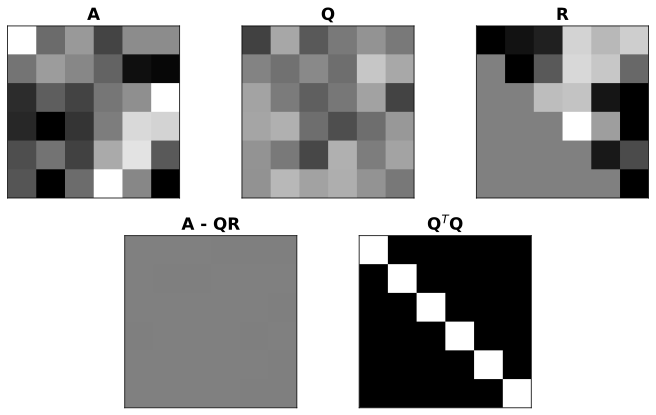

In [3]:
# create a random matrix
A = np.random.randn(6,6)

# QR decomposition
Q,R = np.linalg.qr(A)



# show the matrices
fig = plt.figure(figsize=(10,6))
axs = [0]*5
c = 1.5 # color limits

gs1 = gridspec.GridSpec(2,6)
axs[0] = plt.subplot(gs1[0,:2])
axs[0].imshow(A,vmin=-c,vmax=c,cmap='gray')
axs[0].set_title('A',fontweight='bold')

axs[1] = plt.subplot(gs1[0,2:4])
axs[1].imshow(Q,vmin=-c,vmax=c,cmap='gray')
axs[1].set_title('Q',fontweight='bold')

axs[2] = plt.subplot(gs1[0,4:6])
axs[2].imshow(R,vmin=-c,vmax=c,cmap='gray')
axs[2].set_title('R',fontweight='bold')

axs[3] = plt.subplot(gs1[1,1:3])
axs[3].imshow(A - Q@R,vmin=-c,vmax=c,cmap='gray')
axs[3].set_title('A - QR',fontweight='bold')

axs[4] = plt.subplot(gs1[1,3:5])
axs[4].imshow(Q.T@Q,cmap='gray')
axs[4].set_title(r'Q$^T$Q',fontweight='bold')

# remove ticks from all axes
for a in axs:
  a.set_xticks([])
  a.set_yticks([])

plt.tight_layout()
plt.savefig('Figure_09_01.png',dpi=300)
plt.show()

In [4]:
# QR and matrix sizes

M = 4
N = 14

A = np.random.randn(M,N)
Q,R = np.linalg.qr(A)

# print the results
print(f'Size of A (M,N): {A.shape}')
print(f'Size of Q (M,N): {Q.shape}')
print(f'Size of R (M,N): {R.shape}')

Size of A (M,N): (4, 14)
Size of Q (M,N): (4, 4)
Size of R (M,N): (4, 14)


In [5]:
# illustration of full Q from M>N A

A = np.array([ [1,-1] ]).T

Q,R = np.linalg.qr(A,'complete')
Q*np.sqrt(2)

array([[-1.,  1.],
       [ 1.,  1.]])

# Latihan 1

In [6]:
# compute matrices
Q  = np.linalg.qr( np.random.randn(5,5) )[0]
Qt = Q.T
Qi = np.linalg.inv( Q )

# QtQ
print(np.round( Qt@Q,8 )), print(' ')

# QQt
print(np.round( Q@Qt,8 )), print(' ')

# Q^-1 Q
print(np.round( Qi@Q,8 )), print(' ')

# QQ^-1
print(np.round( Q@Qi,8 ))


[[ 1.  0.  0.  0.  0.]
 [ 0.  1.  0.  0. -0.]
 [ 0.  0.  1.  0. -0.]
 [ 0.  0.  0.  1. -0.]
 [ 0. -0. -0. -0.  1.]]
 
[[ 1.  0. -0.  0. -0.]
 [ 0.  1.  0.  0.  0.]
 [-0.  0.  1.  0.  0.]
 [ 0.  0.  0.  1.  0.]
 [-0.  0.  0.  0.  1.]]
 
[[ 1. -0.  0. -0. -0.]
 [ 0.  1. -0.  0. -0.]
 [ 0. -0.  1.  0. -0.]
 [-0. -0. -0.  1. -0.]
 [-0. -0.  0.  0.  1.]]
 
[[ 1.  0. -0. -0.  0.]
 [ 0.  1.  0.  0.  0.]
 [-0. -0.  1.  0. -0.]
 [ 0. -0.  0.  1. -0.]
 [-0. -0. -0. -0.  1.]]


# Latihan 2

In [7]:
# create the matrix 
m = 4
n = 4
A = np.random.randn(m,n)

# initialize
Q = np.zeros((m,n))


# the GS algo
for i in range(n):
    
    # initialize
    Q[:,i] = A[:,i]
    
    # orthogonalize
    a = A[:,i] # convenience
    for j in range(i): # only to earlier cols
        q = Q[:,j] # convenience
        Q[:,i]=Q[:,i]-np.dot(a,q)/np.dot(q,q)*q
    
    # normalize
    Q[:,i] = Q[:,i] / np.linalg.norm(Q[:,i])

    
# "real" QR decomposition for comparison
Q2,R = np.linalg.qr(A)


# note the possible sign differences.
# seemingly non-zero columns will be 0 when adding
print( np.round( Q-Q2 ,10) ), print(' ')
print( np.round( Q+Q2 ,10) )

[[-0.          1.59229815 -0.171344    0.        ]
 [ 0.          0.8185026   1.61067881  0.        ]
 [-0.         -0.8718102   1.15281427 -0.        ]
 [-0.          0.18597597 -0.21765629  0.        ]]
 
[[-1.06133495  0.          0.         -0.55569412]
 [ 0.76923215  0.          0.          0.37953806]
 [-1.35757119 -0.         -0.         -0.26070425]
 [-0.66245791  0.         -0.          1.86525821]]


# Latihan 3

In [8]:
# create an orthogonal matrix, call it U (to avoid confusing with Q)
U = np.linalg.qr( np.random.randn(6,6) )[0]


# part 2: modulate the column norms
for i in range(U.shape[0]):
  U[:,i] = U[:,i]*(10+i)


# part 3: Change one matrix element
U[0,3] = 0 # this is q_{1,4}


# QR decomp
q,r = np.linalg.qr(U)

# show R and, for part 2, Q'Q
print( np.round(r,3) ), print(' ')
# print( np.round(Q.T@Q,4))

[[ 1.0000e+01  0.0000e+00  0.0000e+00 -7.2500e-01  0.0000e+00 -0.0000e+00]
 [ 0.0000e+00  1.1000e+01  0.0000e+00 -7.9900e-01 -0.0000e+00 -0.0000e+00]
 [ 0.0000e+00  0.0000e+00  1.2000e+01 -3.0900e+00 -0.0000e+00  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.1381e+01 -4.4620e+00  3.9000e-02]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  1.3270e+01  1.3000e-02]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  1.5000e+01]]
 


(None, None)

# Latihan 4

In [9]:
# a function to compute the inverse
def oldSchoolInv(A):

  # matrix size
  m = A.shape[0]


  # abort if non-square
  if not np.diff(A.shape)[0]==0:
    raise Exception('Matrix must be square.')
  
  # abort if singular
  if np.linalg.matrix_rank(A)<m:
    raise Exception('Matrix must be full-rank.')


  # initialize
  M = np.zeros((m,m)) # minors matrix
  G = np.zeros((m,m)) # grid matrix

  # compute minors matrix
  for i in range(m):
    for j in range(m):
      
      # select rows and cols
      rows = [True]*m
      rows[i] = False
      
      cols = [True]*m
      cols[j] = False
      
      # compute the minors
      M[i,j]=np.linalg.det(A[rows,:][:,cols])
      
      # compute Grid
      G[i,j] = (-1)**(i+j)

          
  # compute cofactors matrix
  C = M * G

  # compute adjugate matrix
  return C.T / np.linalg.det(A)

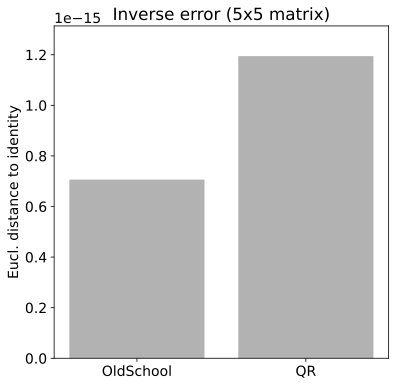

In [10]:
# create a matrix
n = 5
A = np.random.randn(n,n)

# old-school inverse method
Ainv_old = oldSchoolInv(A)
AAi_old  = Ainv_old@A

# via QR
Q,R = np.linalg.qr(A)
Ainv_qr = oldSchoolInv(R)@Q.T
AAi_qr  = Ainv_qr@A



# differences
trueI = np.eye(n)
sse = [0,0] # sse = sum of squared errors
sse[0] = np.sqrt(np.sum((AAi_old-trueI)**2))
sse[1] = np.sqrt(np.sum((AAi_qr-trueI )**2))


# and plot
plt.figure(figsize=(6,6))

plt.bar(range(2),sse,color=[.7,.7,.7])
plt.xticks(range(2),labels=['OldSchool','QR'])
plt.ylim([0,np.max(sse)*1.1])
plt.ylabel('Eucl. distance to identity')
plt.title(f'Inverse error ({n}x{n} matrix)',ha='center')
plt.savefig('Figure_09_03.png',dpi=300)
plt.show()

# Latihan 5

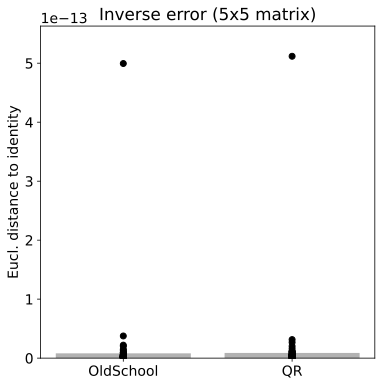

In [11]:
# run experiment

# matrix size
n = 5

numExprs = 100

sse = np.zeros((numExprs,2))

for expi in range(numExprs):

  # create matrix
  A = np.random.randn(n,n)

  # old-school inverse method
  Ainv_old = oldSchoolInv(A)
  AAi_old  = Ainv_old@A

  # via QR
  Q,R = np.linalg.qr(A)
  Ainv_qr = oldSchoolInv(R)@Q.T # using the old-school method
  # Ainv_qr = np.linalg.inv(R)@Q.T # using numpy's inv
  AAi_qr  = Ainv_qr@A

  # differences
  trueI = np.eye(n)
  sse[expi,0] = np.sqrt(np.sum((AAi_old-trueI)**2))
  sse[expi,1] = np.sqrt(np.sum((AAi_qr-trueI )**2))


# and plot
plt.figure(figsize=(6,6))

plt.plot(np.zeros(numExprs),sse[:,0],'ko')
plt.plot(np.ones(numExprs),sse[:,1],'ko')
plt.bar(range(2),np.mean(sse,axis=0),color=[.7,.7,.7])

plt.xticks(range(2),labels=['OldSchool','QR'])
plt.ylim([0,np.max(sse)*1.1])
plt.ylabel('Eucl. distance to identity')
plt.title(f'Inverse error ({n}x{n} matrix)',ha='center')
plt.savefig('Figure_09_04a.png',dpi=300)
plt.show()

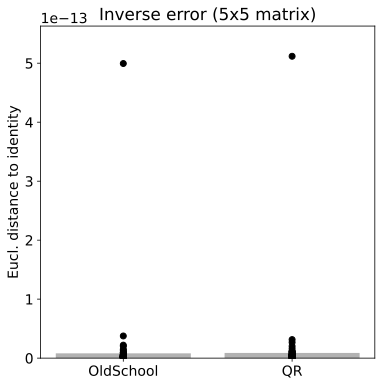

In [12]:
# and plot
plt.figure(figsize=(6,6))

plt.plot(np.zeros(numExprs),sse[:,0],'ko')
plt.plot(np.ones(numExprs),sse[:,1],'ko')
plt.bar(range(2),np.mean(sse,axis=0),color=[.7,.7,.7])

plt.xticks(range(2),labels=['OldSchool','QR'])
plt.ylim([0,np.max(sse)*1.1])
plt.ylabel('Eucl. distance to identity')
plt.title(f'Inverse error ({n}x{n} matrix)',ha='center')
plt.savefig('Figure_09_04b.png',dpi=300)
plt.show()

# Latihan 6

In [13]:
# create a random orthogonal matrix
n = 13
Q,R = np.linalg.qr(np.random.randn(n,n))

# print out the norms
print( np.linalg.norm(Q,2),               # induced 2-norm
       np.sqrt( np.sum(Q**2) )/np.sqrt(n) # manually computed Frobenius norm
)

1.0000000000000004 1.0


In [14]:
# effects of matrix multiplication on vector norm

# a random vector
v = np.random.randn(n,1)

# norms
norm_v  = np.linalg.norm(v)
norm_Qv = np.linalg.norm(Q@v)

# print them
print(norm_v)
print(norm_Qv)

3.843577585191792
3.8435775851917926


# Latihan 7

In [15]:
# the matrix
A = np.random.randn(10,4)

# get R
_,R = np.linalg.qr(A,'complete')

# examine R
np.round(R,3)

array([[ 1.701, -1.034, -0.828, -1.069],
       [ 0.   , -2.976,  0.198, -0.813],
       [ 0.   ,  0.   , -4.43 , -0.847],
       [ 0.   ,  0.   ,  0.   , -2.138],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ]])

In [16]:
# invertible submatrix
Rsub = R[:4,:]

# inverses
Rsub_inv = np.linalg.inv(Rsub)
Rleftinv = np.linalg.pinv(R)

# print out both
print('Full inverse of R submatrix:')
print(np.round(Rsub_inv,3)), print(f'\n\n')

print('Left inverse of R:')
print(np.round(Rleftinv,3))

Full inverse of R submatrix:
[[ 0.588 -0.204 -0.119 -0.169]
 [-0.    -0.336 -0.015  0.134]
 [-0.    -0.    -0.226  0.089]
 [-0.    -0.    -0.    -0.468]]



Left inverse of R:
[[ 0.588 -0.204 -0.119 -0.169  0.     0.     0.     0.     0.     0.   ]
 [-0.    -0.336 -0.015  0.134  0.     0.     0.     0.     0.     0.   ]
 [-0.     0.    -0.226  0.089  0.     0.     0.     0.     0.     0.   ]
 [-0.     0.    -0.    -0.468  0.     0.     0.     0.     0.     0.   ]]


---

## Ringkasan dan Pandangan (Summary and Outlook)

### Ringkasan Bab 9

Kita telah mempelajari matriks ortogonal yang memiliki sifat khusus di mana transpose-nya sama dengan invers-nya. Kita juga mempelajari bagaimana dekomposisi QR memecah matriks menjadi matriks ortogonal Q dan matriks segitiga atas R.

### Pandangan ke Depan

Pada Bab 10, kita akan mempelajari eliminasi Gauss-Jordan untuk penyelesaian persamaan linier secara sistematis dan dekomposisi LU.
